# ICLR 2027 submission figures

Every figure in the paper is built here, from the wandb sweeps and the runs logged under `MICE/`.
Run from `MICE/figs/` with the `omnisafe` env (`/home/kaustubh/anaconda3/envs/omnisafe/bin/python`).

The notebook is in two halves. **Toolkit** is the reusable part -- pulling a sweep, scoring and
picking configs, building mean +/- SEM bands over seeds, and drawing a row of panels; nothing in it
knows about any particular figure. **Figures** is one short cell per figure that calls into it.
Adding figure 2 should mean writing a `Panel` list and a `series` dict, not another plotting
routine.

## Toolkit

### Setup and house style

In [ ]:
from __future__ import annotations

import re
from concurrent.futures import ThreadPoolExecutor, as_completed
from dataclasses import dataclass, field
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.ticker import (FixedLocator, FuncFormatter, MaxNLocator,
                               NullFormatter, NullLocator)

HERE = Path.cwd()                 # MICE/figs
MICE = HERE.parent
DATA = MICE / "analysis_data"
PROJECT = "liam-paull/calibration_rl"

# Authored at the ICLR text width -- a single-column template, so this is also the widest a figure
# can be placed. Sizing to it means \includegraphics[width=\textwidth] scales by 1.0 and every font
# comes out the size it is set to here; authoring wider and letting LaTeX shrink the figure is what
# turns tick labels to mush.
TEXTWIDTH = 5.5

# Categorical slots 1 and 2 of the house palette, in slot order, validated as a pair for CVD and
# normal-vision separation on a light surface. Extend in slot order; never cycle.
# The paper's algorithm colours, from plots/scripts/*.py: CPO blue, PIDLag orange, in every
# figure. SLOTS keeps further categorical hues in fixed order for figures that need more.
ALGO_COLOUR = {"CPO": "#4c72b0", "PIDLag": "#dd8452"}
SLOTS = ["#4c72b0", "#dd8452", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
INK, MUTED, GRID, RULE = "#0e1418", "#7b8792", "#dce2e7", "#b9c2ca"

# Paper-facing names. The data keeps wandb's own algo strings as the join key; this is only what
# the figures print.
ALGO_LABEL = {"TRPOPID": "PIDLag"}


def label_of(algo: str) -> str:
    return ALGO_LABEL.get(algo, algo)

plt.rcParams.update({
    "figure.figsize": (14, 3.0),          # fig1_plot.py's canvas; plot_panels reads it
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
    "font.size": 9,
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "axes.labelcolor": MUTED,
    "axes.edgecolor": GRID,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": GRID,
    "grid.linewidth": 0.6,
    "grid.alpha": 0.3,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.frameon": False,
    "legend.fontsize": 9,
    "lines.linewidth": 1.6,
    "pdf.fonttype": 42,           # TrueType, not Type 3 -- the submission checker rejects Type 3
    "ps.fonttype": 42,
})


def save_fig(fig, stem: str, *, pad: float = 0.02) -> None:
    """Vector PDF for LaTeX, 300 dpi PNG for looking at, both next to this notebook."""
    for ext, kw in (("pdf", {}), ("png", {"dpi": 400})):
        out = HERE / f"{stem}.{ext}"
        fig.savefig(out, bbox_inches="tight", pad_inches=pad, facecolor="white", **kw)
        print(f"wrote {out.name}  ({out.stat().st_size / 1024:.0f} KB)")


def steps_fmt(ax) -> None:
    """Env-step ticks that read 5M, not 5000000."""
    ax.xaxis.set_major_formatter(FuncFormatter(
        lambda v, _: f"{v/1e6:g}M" if v >= 1e6 else (f"{v/1e3:g}k" if v >= 1e3 else f"{v:g}")))

### Pulling a sweep

`load_sweep` caches to `analysis_data/sweep_<id>/history.csv.gz` and only calls wandb when the cache
is missing, so re-running the notebook is offline and fast. Per-run config comes from
`run.metadata["args"]` -- the sweep agent's command line -- because these runs have an empty
`run.config` on wandb, leaving the command line as the only record of which grid point a run is.

`CONFIG_ARGS` maps the sweep's flags onto the frame's config columns. A different sweep varying
different flags means a different mapping passed in, not an edit here.

In [ ]:
DEFAULT_KEYS = ["TotalEnvSteps", "Metrics/EpRet", "Metrics/EpCost", "Metrics/TotalCost",
                "PooledMC/Correlation_r", "PooledMC/Correlation_c"]

# column -> (cli flag, caster). The columns named here become the config identity of a run.
CONFIG_ARGS = {
    "algo":         ("algo", str),
    "seed":         ("seed", int),
    "adv":          ("adv-estimation-method", str),
    "update_iters": ("algo-cfgs.update-iters", int),
    "critic_lr":    ("model-cfgs.critic.lr", float),
    "cost_limit":   ("cost-limit", float),
}
CFG = ["algo", "adv", "update_iters", "critic_lr"]     # what identifies a grid point, minus seed


def pull_sweep(sweep: str, *, project: str = PROJECT, keys: list[str] = DEFAULT_KEYS,
               config_args: dict = CONFIG_ARGS, max_workers: int = 10) -> pd.DataFrame:
    """Every run in a sweep as one long-form frame: history columns plus config columns.

    Each run is a handful of small, independent network calls, so this is I/O-bound -- a thread
    pool, not a process pool, and 10 workers turns 80 sequential pulls into about one pull's
    wall clock.
    """
    import wandb

    def one(run_id: str) -> pd.DataFrame:
        run = wandb.Api(timeout=90).run(f"{project}/{run_id}")   # Api is not documented thread-safe
        args = dict(m.groups() for a in (run.metadata or {}).get("args", [])
                    if (m := re.match(r"^--([^=]+)=(.*)$", a)))
        h = run.history(keys=keys, pandas=True, samples=100_000)
        for c in h.columns:                       # wandb hands these back as object columns
            h[c] = pd.to_numeric(h[c], errors="coerce")
        h = h.sort_values("TotalEnvSteps").reset_index(drop=True)
        cfg = {col: (cast(args[flag]) if flag in args else None)
               for col, (flag, cast) in config_args.items()}
        return h.assign(run_id=run_id, **cfg)

    ids = [r.id for r in wandb.Api(timeout=90).sweep(f"{project}/{sweep}").runs]
    with ThreadPoolExecutor(max_workers=max_workers) as pool:
        futs = [pool.submit(one, rid) for rid in ids]
        return pd.concat([f.result() for f in as_completed(futs)], ignore_index=True)


def load_sweep(sweep: str, *, refresh: bool = False, **pull_kw) -> pd.DataFrame:
    """Cached `pull_sweep`. Pass refresh=True to re-pull a sweep that has since gained runs."""
    cache = DATA / f"sweep_{sweep}" / "history.csv.gz"
    if cache.exists() and not refresh:
        print(f"cache: {cache.relative_to(MICE)}")
        return pd.read_csv(cache)
    df = pull_sweep(sweep, **pull_kw)
    cache.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(cache, index=False)
    print(f"pulled {df.run_id.nunique()} runs -> {cache.relative_to(MICE)}")
    return df

### Scoring configs and picking a winner

Each run is reduced to one number and configs are ranked by that number averaged over their 5 seeds.
`BASIS` below picks what the number is:

| basis | score | best is |
|---|---|---|
| `"ratio"` | mean `EpRet` over the last 10% of training / final `Metrics/TotalCost` | highest |
| `"ret"` | mean `EpRet` over the last 10% of training | highest |
| `"cost"` | final `Metrics/TotalCost`, the cumulative cost paid over the run | lowest |

`ratio` asks what return was bought per unit of cost paid, `ret` ignores cost entirely, and `cost`
ignores return -- so `cost` will happily crown a config that learned nothing, and is there to be
read next to the others rather than alone. The tail window means the score reads final policy
quality rather than how fast the run got there; `TAIL_FRAC` is the knob.

To rank on something else, pass a `Score(fn, higher_is_better, label)` of your own as `basis` --
nothing downstream sees anything but the resulting column.

In [ ]:
@dataclass(frozen=True)
class Score:
    """A basis for ranking configs: how to reduce a run to a number, and which end is better."""
    fn: callable                          # (run_frame, tail_frame) -> float
    higher_is_better: bool
    label: str


# The bases you can rank on. `tail` is the last TAIL_FRAC of the run, `g` the whole run.
SCORES = {
    "ratio": Score(lambda g, tail: tail["Metrics/EpRet"].mean() / g["Metrics/TotalCost"].iloc[-1],
                   True,  "EpRet / TotalCost"),
    "ret":   Score(lambda g, tail: tail["Metrics/EpRet"].mean(),
                   True,  "EpRet"),
    "cost":  Score(lambda g, tail: g["Metrics/TotalCost"].iloc[-1],
                   False, "TotalCost"),
}
TAIL_FRAC = 0.10          # EpRet is read over the last tenth of training, not at the final epoch


def as_score(basis: str | Score) -> Score:
    """Accept a key from SCORES or a Score of your own."""
    if isinstance(basis, Score):
        return basis
    try:
        return SCORES[basis]
    except KeyError:
        raise KeyError(f"unknown basis {basis!r}; pick one of {sorted(SCORES)} or pass a Score") from None


def score_runs(df: pd.DataFrame, *, cfg: list[str] = CFG, basis: str | Score = "ratio",
               tail_frac: float = TAIL_FRAC) -> pd.DataFrame:
    """One row per run: its config, its score on `basis`, and the quantities behind the score."""
    score = as_score(basis)
    rows = []
    for keys, g in df.groupby(cfg + ["seed", "run_id"]):
        g = g.sort_values("TotalEnvSteps")
        tail = g.tail(max(1, int(round(len(g) * tail_frac))))
        rows.append(dict(zip(cfg + ["seed", "run_id"], keys),
                         score=score.fn(g, tail),
                         ret_tail=tail["Metrics/EpRet"].mean(),
                         cost_tail=tail["Metrics/EpCost"].mean(),
                         total_cost=g["Metrics/TotalCost"].iloc[-1]))
    return pd.DataFrame(rows)


def rank_configs(per_run: pd.DataFrame, *, cfg: list[str] = CFG, by: str = "algo",
                 basis: str | Score = "ratio") -> pd.DataFrame:
    """Seed-averaged score per config, best first within each `by` group -- where "best" is the
    high end for EpRet and the ratio, and the low end for TotalCost."""
    score = as_score(basis)
    sem = lambda s: s.std(ddof=1) / np.sqrt(len(s))
    out = (per_run.groupby(cfg)
           .agg(score=("score", "mean"), score_sem=("score", sem), ret_tail=("ret_tail", "mean"),
                cost_tail=("cost_tail", "mean"), total_cost=("total_cost", "mean"),
                n_seeds=("seed", "nunique"))
           .reset_index())
    return (out.sort_values([by, "score"], ascending=[True, not score.higher_is_better])
            .reset_index(drop=True))


def best_configs(df: pd.DataFrame, *, cfg: list[str] = CFG, by: str = "algo",
                 basis: str | Score = "ratio", **score_kw):
    """(winning config per `by` group, the full ranking) -- the ranking is worth reading."""
    per_run = score_runs(df, cfg=cfg, basis=basis, **score_kw)
    ranked = rank_configs(per_run, cfg=cfg, by=by, basis=basis)
    return ranked.groupby(by).head(1).set_index(by, drop=False), ranked


def runs_for(df: pd.DataFrame, cfg_row: pd.Series, *, cfg: list[str] = CFG) -> pd.DataFrame:
    """Every seed of one config, selected by the config columns of a ranking row."""
    keys = [c for c in cfg if c in cfg_row.index]
    if not keys:
        raise KeyError(f"none of {cfg} present in the row -- it cannot identify a config")
    mask = np.ones(len(df), dtype=bool)
    for c in keys:
        mask &= (df[c] == cfg_row[c]).to_numpy()
    return df[mask]

### Bands and panels

`seed_band` is the aggregation: rolling-average each seed first when asked, then take the mean and
standard error across seeds at each x. The band is the SEM, the spread of the *mean* -- narrower
than seed-to-seed spread by construction, and the right thing when the question is where the mean
lies.

`plot_panels` draws one row of panels for a set of series. A figure is then a list of `Panel`s and a
`{label: (runs, colour)}` dict, which is all figure 1 below supplies.

In [ ]:
def seed_band(df: pd.DataFrame, col: str, *, x: str = "TotalEnvSteps", smooth: int = 0,
              min_seeds: int = 2, spread: str = "sd") -> pd.DataFrame:
    """Columns x, y (mean over seeds), err, n.

    spread="sd"  -- seed-to-seed spread, what plots/scripts/fig1_plot.py draws
    spread="sem" -- spread of the mean itself, narrower by sqrt(n)

    Smoothing is per seed, before aggregating, so the band is seed spread rather than per-epoch
    rollout noise. A centred rolling mean with min_periods=1 is the edge-normalised running mean
    fig1_plot.py builds with np.convolve.
    """
    d = df[[x, "seed", col]].dropna().copy()
    if d.duplicated([x, "seed"]).any():
        raise ValueError(f"{col}: more than one run per seed at the same {x} -- "
                         "the runs passed in are not a single config")
    if smooth:
        d[col] = d.groupby("seed")[col].transform(
            lambda s: s.rolling(smooth, center=True, min_periods=1).mean())
    g = d.groupby(x)[col].agg(y="mean", sd=lambda s: s.std(ddof=1), n="size").reset_index()
    g["err"] = g["sd"] if spread == "sd" else g["sd"] / np.sqrt(g["n"])
    return g.loc[g["n"] >= min_seeds, [x, "y", "err", "n"]].rename(columns={x: "x"})


def plot_band(ax, band: pd.DataFrame, colour: str, label: str | None = None, *,
              xdiv: float = 1.0, **kw) -> None:
    ax.fill_between(band.x / xdiv, band.y - band.err, band.y + band.err,
                    color=colour, alpha=0.18, lw=0, zorder=2)
    ax.plot(band.x / xdiv, band.y, color=colour, label=label, zorder=3, **kw)


@dataclass
class Panel:
    """One panel: which column to draw, how to label it, and how to frame it."""
    col: str
    title: str | None = None              # above the axes
    ylabel: str | None = None             # fig1_plot.py labels the y axis instead
    caption: str | None = None            # italic "(a) ..." under the axes
    smooth: int = 0                       # rolling window in epochs, per seed; 0 = raw
    ylim: tuple[float, float] | None = None
    hline: float | None = None            # a reference level (cost limit, zero, ...)
    hline_label: str | None = None
    hline_label_size: float = 8.0
    yticks: list[float] | None = None


def plot_panels(panels: list[Panel], series: dict[str, tuple[pd.DataFrame, str]], *,
                x: str = "TotalEnvSteps", width: float | None = None, height: float | None = None,
                xlabel: str = "environment steps", xscale: str = "linear", xdiv: float = 1.0,
                xticks: list[float] | None = None, xticklabels: list[str] | None = None,
                xlim: tuple[float, float] | None = None, spread: str = "sd",
                legend: bool = True, legend_y: float = 1.0, wspace: float = 0.26,
                title_size: float | None = None, caption_y: float = -0.42,
                constrained: bool = True):
    """A row of panels, one mean +/- `spread` curve per series in each. Returns (fig, axes).

    `xdiv` rescales the x axis (1e6 to read environment steps in millions, as the paper does);
    `xticks` are then in those same units.
    """
    w, h = plt.rcParams["figure.figsize"]
    fig, axes = plt.subplots(1, len(panels), figsize=(width or w, height or h),
                             constrained_layout=constrained)
    axes = np.atleast_1d(axes)

    for ax, p in zip(axes, panels):
        for label, (runs, colour) in series.items():
            band = seed_band(runs, p.col, x=x, smooth=p.smooth, spread=spread)
            if len(band):
                plot_band(ax, band, colour, label, xdiv=xdiv)
        if p.hline is not None:
            ax.axhline(p.hline, color="0.4", ls="--", lw=1.0, zorder=4)
            if p.hline_label:
                ax.text(0.03, p.hline, p.hline_label, color="0.4", fontsize=p.hline_label_size,
                        ha="left", va="bottom", transform=ax.get_yaxis_transform(), zorder=5)
        if p.title:  ax.set_title(p.title, color=INK, pad=4,
                                  **({"fontsize": title_size} if title_size else {}))
        if p.ylabel: ax.set_ylabel(p.ylabel, color=INK)
        if p.caption:
            ax.text(0.5, caption_y, p.caption, style="italic", ha="center", transform=ax.transAxes)
        if p.ylim:   ax.set_ylim(*p.ylim)
        if p.yticks: ax.set_yticks(p.yticks)
        else:        ax.yaxis.set_major_locator(MaxNLocator(5))

        ax.set_xscale(xscale)
        if xticks is not None:
            ax.xaxis.set_major_locator(FixedLocator(xticks))
            ax.xaxis.set_minor_locator(NullLocator())
            ax.set_xticklabels(xticklabels if xticklabels is not None else
                               [f"{t:g}" for t in xticks])
        elif xdiv == 1.0:
            steps_fmt(ax)
        if xlim:     ax.set_xlim(*xlim)
        ax.set_xlabel(xlabel)
        ax.grid(alpha=0.3, lw=0.6)

    if legend and len(series) > 1:
        handles = [Line2D([], [], color=c, lw=2.2, label=lbl) for lbl, (_, c) in series.items()]
        fig.legend(handles=handles, loc="lower center", ncol=len(series), frameon=False,
                   bbox_to_anchor=(0.5, legend_y))
    if not constrained:
        fig.subplots_adjust(wspace=wspace)
    return fig, axes

## Figures

### Figure 1 -- sweep `lsaldj7r`

CPO and TRPOPID on `SafetyPointGoal1-v0`, cost limit 10, 10.24M env steps. The sweep is a full grid
over `adv-estimation-method` x `algo-cfgs.update-iters` x `model-cfgs.critic.lr`: 8 configs per
algorithm, 5 seeds each, 80 runs.

Four panels over environment steps -- `EpRet`, `EpCost` against the cost limit, and the pooled
critic-vs-Monte-Carlo-true-value correlation for reward and for cost. One curve per algorithm at
that algorithm's best config by the `EpRet`/`TotalCost` score, banded by standard error over its 5
seeds. `PooledMC/*` is logged on eval epochs only (37 points per run, every 5th epoch), which is why
the right-hand panels are sparser than the left-hand two.

In [ ]:
# Which config each algorithm is shown at: "ratio" (EpRet/TotalCost), "ret" (EpRet alone) or
# "cost" (TotalCost alone). See the table above.
BASIS = "ratio"

hist = load_sweep("lsaldj7r")
print(f"{hist.run_id.nunique()} runs | {hist.groupby(CFG).ngroups} configs | "
      f"{sorted(hist.groupby(CFG).seed.nunique().unique())} seeds per config")

best, ranking = best_configs(hist, basis=BASIS)
sc = as_score(BASIS)
print(f"\nbest config per algorithm by {sc.label} ({'highest' if sc.higher_is_better else 'lowest'} wins):")
for algo, row in best.iterrows():
    print(f"{label_of(algo):<8} adv={row.adv:<5} update_iters={int(row.update_iters):<3} "
          f"critic_lr={row.critic_lr:g}  score={row.score:.3g}  "
          f"(EpRet {row.ret_tail:.1f}, EpCost {row.cost_tail:.1f}, TotalCost {row.total_cost:.3g})")

ranking.style.format({"score": "{:.3g}", "score_sem": "{:.2g}", "ret_tail": "{:.2f}",
                      "cost_tail": "{:.2f}", "total_cost": "{:.4g}", "critic_lr": "{:g}"})

wrote fig1_sweep_overview.pdf  (58 KB)
wrote fig1_sweep_overview.png  (188 KB)


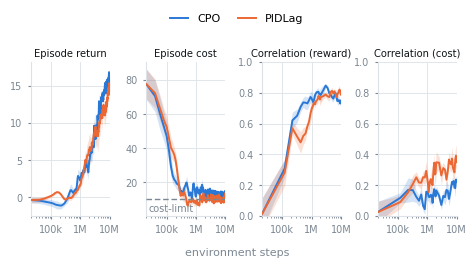

In [ ]:
# Figure 1, following plots/scripts/fig1_plot.py: y-axis labels rather than titles, italic
# panel captions, a +-1 sd band over seeds, a 5-epoch running mean on the return/cost curves, and
# the x axis in millions of environment steps on a log scale.
plt.rcParams["figure.figsize"] = (14, 3.0)

COST_LIMIT = float(hist.cost_limit.dropna().iloc[0])
M = 1e6

panels = [
    Panel("Metrics/EpRet",  ylabel="Episode return", caption="(a) Episode return", smooth=5),
    Panel("Metrics/EpCost", ylabel="Episode cost",   caption="(b) Episode cost",   smooth=5,
          hline=COST_LIMIT, hline_label="limit"),
    Panel("PooledMC/Correlation_r", ylabel=r"Corr($\hat V_r$, $\bar G^r$)",
          caption="(c) Reward-value correlation", ylim=(-0.25, 1.0), hline=0.0),
    Panel("PooledMC/Correlation_c", ylabel=r"Corr($\hat V_c$, $\bar G^c$)",
          caption="(d) Cost-value correlation", ylim=(-0.25, 1.0), hline=0.0),
]
series = {label_of(algo): (runs_for(hist, best.loc[algo]), ALGO_COLOUR[label_of(algo)])
          for algo in best.index}

fig, axes = plot_panels(panels, series, xscale="log", xdiv=M, xlim=(2e4 / M, 1.05e7 / M),
                        xticks=[0.1, 1, 10], xticklabels=["0.1", "1", "10"],
                        xlabel="Environment steps (millions)", spread="sd")
save_fig(fig, "fig1")

## Probe-level evaluation data

Figure 1 reads scalars from the run history. Everything below needs the raw probe data the runs log
as `eval_data` artifacts: for each evaluation checkpoint, a critic prediction and K=10 Monte-Carlo
rollout returns per probe state.

The tree is the one `plots/scripts/download_sweep.py` writes, and the loader is
`plots/common/sweep_data.py` reduced to what these figures use:

```
eval_data_lsaldj7r_<algo>/<cell>/seed<N>/epoch_*.pkl
```

`<cell>` is `<adv>_iters<update_iters>_lr<critic_lr>`, so it names a grid point of the sweep and
the notebook can go straight from the config it picked to the right directory. Only the picked
cells were downloaded (5 seeds x 37 checkpoints each, ~320 MB); a different `BASIS` that picks a
different cell needs its own download.

One departure from `download_sweep.py`: that script reads `run.config` to name the cell, which is
empty for every run in this sweep, so the download here derives cell and seed from
`run.metadata["args"]` exactly as `pull_sweep` does.

In [ ]:
import glob
import os
import pickle


@dataclass
class EvalPoint:
    """One evaluation checkpoint for one run: predictions and rollout returns over probe states."""
    epoch: int
    K: int
    pred: dict[str, np.ndarray]     # 'r' / 'c' -> (n_states,)
    G: dict[str, np.ndarray]        # 'r' / 'c' -> (n_states, K)

    @property
    def n_states(self) -> int:
        return len(self.G["c"])


EVAL_ROOT = {"CPO": MICE / "eval_data_lsaldj7r_cpo", "PIDLag": MICE / "eval_data_lsaldj7r_pidlag"}


def _blocks(d: dict):
    """The probe sets a checkpoint holds: all states pooled, the t=0 study, and per-step strata."""
    yield "pooled", d["pooled"]
    yield "mc_study", d["mc_study"]
    for step, sub in sorted(d["intermediate_study"].items()):
        yield f"intermediate:{step}", sub


def load_eval_points(directory, block: str = "pooled") -> list[EvalPoint]:
    """Every epoch_*.pkl in one seed's directory, in epoch order.

    `returns` is a pure sampled discounted sum with no critic value in its tail, which is what
    makes it usable as a reference for the critic; `target` is the training-style regression
    target and does carry the critic, so it is deliberately not loaded here.
    """
    out = []
    for path in sorted(glob.glob(os.path.join(str(directory), "epoch_*.pkl"))):
        with open(path, "rb") as fh:
            d = pickle.load(fh)
        sub = dict(_blocks(d)).get(block)
        if sub is None:
            raise KeyError(f"{path}: no block {block!r}")
        raw = sub["raw"]
        G = {h: np.asarray(raw[h]["returns"], dtype=float) for h in ("r", "c")}
        pred = {h: np.asarray(raw[h]["pred"], dtype=float) for h in ("r", "c")}
        out.append(EvalPoint(epoch=int(d["epoch"]), K=G["c"].shape[1], pred=pred, G=G))
    return sorted(out, key=lambda p: p.epoch)


def cell_name(cfg_row: pd.Series) -> str:
    """The sweep's directory name for a config: gae_iters2_lr0.0001."""
    return f"{cfg_row.adv}_iters{int(cfg_row.update_iters)}_lr{cfg_row.critic_lr:g}"

def fetch_eval_artifacts(run_id: str, dest, *, project: str = PROJECT,
                         art_type: str = "eval_data") -> int:
    """Download one run's artifacts of `art_type` into `dest`. Returns how many were new."""
    import wandb

    dest = Path(dest)
    dest.mkdir(parents=True, exist_ok=True)
    run = wandb.Api(timeout=180).run(f"{project}/{run_id}")      # one Api per thread
    got = 0
    for art in run.logged_artifacts():
        if art.type != art_type:
            continue
        for f in art.files():
            if f.name.lower().endswith(".pkl") and not (dest / f.name).exists():
                f.download(root=str(dest), replace=False)
                got += 1
    return got


def download_eval_data(label: str, cfg_row: pd.Series, df: pd.DataFrame | None = None, *,
                       workers: int = 5) -> Path:
    """Fetch the probe data for one config into the tree load_probe_seeds reads.

    plots/scripts/download_sweep.py names the cell from run.config, which is empty for every run
    in this sweep; the seed -> run_id mapping here comes from the pulled history instead, which
    carries the config columns parsed out of run.metadata["args"].
    """
    df = hist if df is None else df
    root = Path(EVAL_ROOT[label]) / cell_name(cfg_row)
    seeds = runs_for(df, cfg_row).groupby("seed").run_id.first().to_dict()
    print(f"downloading {label} {cell_name(cfg_row)}: {len(seeds)} seeds -> {root} "
          f"(~30 MB per seed)")
    with ThreadPoolExecutor(max_workers=workers) as pool:
        futs = {pool.submit(fetch_eval_artifacts, rid, root / f"seed{int(sd)}"): (sd, rid)
                for sd, rid in sorted(seeds.items())}
        for f in as_completed(futs):
            sd, rid = futs[f]
            print(f"  seed{int(sd)} ({rid}): +{f.result()} files")
    return root


def load_probe_seeds(label: str, cfg_row: pd.Series, block: str = "pooled",
                     download: bool = True) -> list[list[EvalPoint]]:
    """One list of checkpoints per seed, for the config this notebook picked.

    Downloads the tree the first time it is asked for, so a fresh checkout needs nothing but
    wandb credentials.
    """
    root = Path(EVAL_ROOT[label]) / cell_name(cfg_row)
    if not root.is_dir():
        if not download:
            raise FileNotFoundError(f"{root} not downloaded; call download_eval_data first")
        download_eval_data(label, cfg_row)
    seeds = {int(p.name[4:]): load_eval_points(p, block) for p in sorted(root.glob("seed*"))}
    if not seeds:
        raise FileNotFoundError(f"{root} holds no seed*/epoch_*.pkl")
    return [pts for _, pts in sorted(seeds.items()) if pts]

## Figure 2 -- what the cost critic gets right and wrong

Ported from `plots/scripts/fig2_plot.py`, with one change: the configuration is whichever one this
notebook picked for each algorithm, rather than the hardcoded `gae_iters2_lr0.0001`.

Probe states are grouped by their *true* value, the reference $\bar G^c$: low value below
$\gamma^{500}$, high value at or above $\gamma^5$, intermediate between. "High value" is a
statement about the cost-to-go, not about whether the state is safe to be in.

The statistics per checkpoint, all computed on the cost head:

- **signed error** $\hat V_c - \bar G^c$, over all probes and within each true-value group
- **AUROC** (Mann-Whitney) for ranking high-value states above the rest, with a **split-half
  ceiling**: the same statistic computed with one half of each state's rollouts scoring the other
  half, i.e. what a perfect critic could reach given a 10-rollout reference
- **share** of probes in each value group, which moves a lot over training
- $s$ and $\beta$, the spread ratio and regression slope of prediction on reference

The dash-dot rule marks where the seed-mean episodic cost first reaches the limit: everything left
of it is the constraint-reduction phase.

In [ ]:
GAMMA = 0.99                       # cost_gamma in every run
SPE = 20000                        # steps per epoch
T_LOW, T_HIGH = GAMMA ** 500, GAMMA ** 5

# Value groups are their own palette: the algorithm colours are blue and orange everywhere else.
GROUPS = [("low value", "#bdbdbd"), ("intermediate value", "#9e9ac8"), ("high value", "#c44e52")]
DEFS = {"low value": r"$\tilde{V}_c < \gamma^{500}$",
        "intermediate value": r"$\gamma^{500} \leq \tilde{V}_c < \gamma^{5}$",
        "high value": r"$\tilde{V}_c \geq \gamma^{5}$"}
SCATTER_EPOCH = 10                 # 0.22M steps, before either algorithm reaches the limit
THRESH_V = [4.0, 2.0, 1.0] + [GAMMA ** t for t in (5, 10, 25, 50, 100, 200, 500)]
THRESH_LAB = ["4", "2", r"$1{=}\gamma^0$", r"$\gamma^5$", r"$\gamma^{10}$", r"$\gamma^{25}$",
              r"$\gamma^{50}$", r"$\gamma^{100}$", r"$\gamma^{200}$", r"$\gamma^{500}$"]
TICKS = [3e4, 1e5, 3e5, 1e6, 3e6, 1e7]
TICKLABELS = ["30k", "100k", "300k", "1M", "3M", "10M"]
# strata t = 0, 100, 300, 500, 700, 900 stand for episode steps [0,50), [50,200), [200,400), ...
STRATUM_W = np.array([50, 150, 200, 200, 200, 200]) / 1000
LINTHRESH = 0.01                   # symlog: below this the scatter axes are linear, so zero is drawable


def avg_ranks(x: np.ndarray) -> np.ndarray:
    """Ranks of x, ties sharing their average rank."""
    _, inv, counts = np.unique(x, return_inverse=True, return_counts=True)
    return (np.cumsum(counts) - (counts - 1) / 2.0)[inv]


def auroc(score: np.ndarray, label: np.ndarray) -> float:
    """Probability that a labelled state outranks an unlabelled one (Mann-Whitney)."""
    n1 = int(label.sum())
    n0 = len(label) - n1
    if n1 == 0 or n0 == 0:
        return np.nan
    return float((avg_ranks(score)[label].sum() - n1 * (n1 + 1) / 2) / (n1 * n0))


def wauroc(score, label, w):
    """AUROC with per-probe weights, for the step-weighting check."""
    pos, neg = np.where(label)[0], np.where(~label)[0]
    if not len(pos) or not len(neg):
        return np.nan
    d = score[pos][:, None] - score[neg][None, :]
    W = w[pos][:, None] * w[neg][None, :]
    return float((((d > 0) + 0.5 * (d == 0)).astype(float) * W).sum() / W.sum())


def group(v: np.ndarray) -> list[np.ndarray]:
    return [v < T_LOW, (v >= T_LOW) & (v < T_HIGH), v >= T_HIGH]


def point(pred: np.ndarray, G: np.ndarray, weighted: bool = False) -> dict[str, float]:
    """Every per-checkpoint statistic figure 2 draws or prints."""
    gbar = G.mean(1)
    n, K = G.shape
    w = np.repeat(STRATUM_W / (n // 6), n // 6) if weighted else np.ones(n) / n
    e = pred - gbar
    out = {"auroc": wauroc(pred, gbar >= T_HIGH, w) if weighted else auroc(pred, gbar >= T_HIGH),
           "signed_all": float((w * e).sum() / w.sum()),
           "neg": float((w * (pred < 0)).sum() / w.sum())}
    h1, h2 = G[:, :K // 2].mean(1), G[:, K // 2:].mean(1)
    out["auroc_ceil"] = np.nanmean([auroc(h1, h2 >= T_HIGH), auroc(h2, h1 >= T_HIGH)])
    for tag, masks in (("true", group(gbar)), ("pred", group(pred))):
        for (g, _), m in zip(GROUPS, masks):
            out[f"{tag}_{g}"] = float((w[m] * e[m]).sum() / w[m].sum()) if m.any() else np.nan
    for (g, _), m in zip(GROUPS, group(gbar)):
        out[f"share_{g}"] = float(w[m].sum() / w.sum())
    for i, v in enumerate(THRESH_V):
        lab = gbar >= v
        out[f"auroc_v{i}"] = wauroc(pred, lab, w) if weighted else auroc(pred, lab)
        out[f"prev_v{i}"] = float((w * lab).sum() / w.sum())
    var_v = gbar.var(ddof=1) - G.var(1, ddof=1).mean() / K
    cov = np.cov(pred, gbar)[0, 1]
    out["s"] = float(np.sqrt(pred.var(ddof=1) / var_v)) if var_v > 0 else np.nan
    out["beta"] = float(cov / pred.var(ddof=1)) if pred.var() > 0 else np.nan
    return out


def beta_crossing(runs: pd.DataFrame, limit: float = None) -> float:
    """Steps at which the seed-mean episodic cost first reaches the limit.

    Everything to the left is the constraint-reduction phase -- the safe exploration the paper is
    about -- and it is where the critic diagnostics have to be read, not at convergence.
    """
    limit = COST_LIMIT if limit is None else limit
    m = runs.groupby("TotalEnvSteps")["Metrics/EpCost"].mean()
    below = m.index[m.to_numpy() <= limit]
    return float(below[0]) if len(below) else float(m.index[-1])


def logx(ax) -> None:
    ax.set_xscale("log")
    ax.set_xlim(1.5e4, 1.03e7)
    ax.xaxis.set_major_locator(FixedLocator(TICKS))
    ax.xaxis.set_minor_locator(NullLocator())
    ax.set_xticklabels(TICKLABELS)
    ax.set_xlabel("Total env steps")


def seed_curve(ax, x, M, col, lw=1.6, ls="-", label=None) -> None:
    """Seed mean with a +-1 standard-error band, over a (seeds, checkpoints) array.

    The full range over 5 seeds is dominated by whichever seed is most extreme at each checkpoint
    and buries the curves it surrounds, so the band is the standard error.
    """
    m = np.nanmean(M, 0)
    se = np.nanstd(M, 0, ddof=1) / np.sqrt(np.sum(np.isfinite(M), 0))
    ax.plot(x, m, color=col, lw=lw, ls=ls, label=label)
    ax.fill_between(x, m - se, m + se, color=col, alpha=0.18, lw=0)

In [ ]:
# Build the per-algorithm statistics once: 5 seeds x 37 checkpoints x ~102 probes per algorithm.
D = {}
for algo in best.index:
    label = label_of(algo)
    cfg = best.loc[algo]
    runs = load_probe_seeds(label, cfg)
    D[label] = {
        "cell": cell_name(cfg),
        "colour": ALGO_COLOUR[label],
        "x": np.array([(p.epoch + 1) * SPE for p in runs[0]], float),
        "x0": beta_crossing(runs_for(hist, cfg)),
        "P":  [[point(p.pred["c"], p.G["c"]) for p in pts] for pts in runs],
        "PW": [[point(p.pred["c"], p.G["c"], weighted=True) for p in pts] for pts in runs],
        "scatter": [next(p for p in pts if p.epoch == SCATTER_EPOCH) for pts in runs],
    }
    d = D[label]
    print(f"{label:<7} cell {d['cell']:<22} {len(runs)} seeds x {len(d['x'])} checkpoints, "
          f"{runs[0][0].n_states} probes, K={runs[0][0].K} | cost reaches the limit at "
          f"{d['x0'] / 1e6:.2f}M steps | scatter at {(SCATTER_EPOCH + 1) * SPE / 1e6:.2f}M")

In [ ]:
def algo_figure(name: str, d: dict, out: str, linear: bool = False):
    """Figure 2 for one algorithm: scatter, signed error, error by value group, AUROC."""
    col = d["colour"]
    fig, axes = plt.subplots(1, 4, figsize=(17, 3.8), constrained_layout=True)
    x, P = d["x"], d["P"]                      # every checkpoint, epoch 0 (20k steps) included

    # (a) critic against reference at one descent-phase checkpoint, coloured by true value group
    ax = axes[0]
    pts = d["scatter"]
    pred = np.concatenate([p.pred["c"] for p in pts])
    gbar = np.concatenate([p.G["c"].mean(1) for p in pts])
    for (g, gc), m in reversed(list(zip(GROUPS, group(gbar)))):
        ax.scatter(gbar[m], pred[m], s=12, color=gc, alpha=0.7, edgecolors="none",
                   label=f"{g}: {DEFS[g]}")
    px = 0.05 * np.ptp(gbar)
    xl = (gbar.min() - px, gbar.max() + px)
    xs = np.linspace(*xl, 800)                 # y = x sampled densely: symlog y bends the identity line
    ax.plot(xs, xs, color="0.3", ls="--", lw=1, label="perfect prediction")
    if linear:
        py = 0.05 * np.ptp(pred)
        ax.set_xlim(*xl)
        ax.set_ylim(pred.min() - py, pred.max() + py)
    else:
        # symlog on both axes: the critic predicts negative values, which no log axis takes, and
        # the reference is zero on a large share of the probes
        ax.set_xscale("symlog", linthresh=LINTHRESH)
        ax.set_yscale("symlog", linthresh=LINTHRESH)
        ax.set_xlim(min(gbar.min() * 1.3, -0.02) if gbar.min() < 0 else -0.003, gbar.max() * 1.4)
        ax.set_ylim(pred.min() * 1.3, pred.max() * 1.4)
    ax.set_xlabel(r"Reference $\tilde V_c$ (10 rollouts)" + ("" if linear else ", symlog"))
    ax.set_ylabel(r"Cost critic prediction $\hat V_c$" + ("" if linear else ", symlog"))
    ax.set_title(f"Critic vs reference, {(SCATTER_EPOCH + 1) * SPE / 1e6:.2f}M steps")
    h_, l_ = ax.get_legend_handles_labels()
    order = [l_.index(f"{g}: {DEFS[g]}") for g, _ in GROUPS] + [l_.index("perfect prediction")]
    ax.legend([h_[i] for i in order], [l_[i] for i in order], fontsize=7.5, frameon=False,
              loc="lower right")

    # (b) signed error over all probes
    ax = axes[1]
    seed_curve(ax, x, np.array([[p["signed_all"] for p in s_] for s_ in P]), col)
    ax.axhline(0, color="0.3", lw=1)
    ax.set_ylabel(r"$\hat V_c - \tilde{V}_c^{\,c}$, all probes")
    ax.set_title("Signed error, all probe states")

    # (c) the same, split by the group the reference puts each probe in
    ax = axes[2]
    for g, gc in GROUPS:
        seed_curve(ax, x, np.array([[p[f"true_{g}"] for p in s_] for s_ in P]), gc, label=g)
    ax.axhline(0, color="0.3", lw=1)
    ax.set_ylabel(r"$\hat V_c - \tilde{V}_c^{\,c}$")
    ax.set_title("Signed error by true value group")
    ax.legend(fontsize=8, frameon=False, loc="lower right")

    # (d) ranking rather than magnitude, against what a perfect critic could reach
    ax = axes[3]
    seed_curve(ax, x, np.array([[p["auroc"] for p in s_] for s_ in P]), col)
    ax.plot(x, np.nanmean([[p["auroc_ceil"] for p in s_] for s_ in P], 0), color=col, lw=1.1, ls=":")
    ax.axhline(0.5, color="0.3", lw=1)
    ax.set_ylim(0.3, 1.02)
    ax.set_ylabel(r"AUROC (Mann-Whitney), high value $= \tilde{V}_c \geq \gamma^5$")
    ax.set_title("The critic as a binary classifier")
    ax.legend(handles=[Line2D([], [], color=col, lw=1.6, label="critic"),
                       Line2D([], [], color="0.3", lw=1.1, ls=":", label="split-half ceiling")],
              fontsize=8, frameon=False, loc="lower right")

    for ax in axes[1:]:
        logx(ax)
        ax.axvline(d["x0"], color="0.4", ls="-.", lw=0.9)
    for ax in axes:
        ax.grid(alpha=0.3, lw=0.6)
    fig.suptitle(f"{name} on PointGoal1: cost critic quality on its own probe states "
                 f"(5 seeds; mean $\pm$ 1 s.e.; dash-dot: cost reaches the limit)",
                 fontsize=10.5, color=col)
    save_fig(fig, out)
    return fig


for label, d in D.items():
    slug = label.lower()
    algo_figure(label, d, f"fig2_{slug}")
    algo_figure(label, d, f"fig2_{slug}_linear", linear=True)

In [ ]:
def threshold_figure(D: dict, out: str):
    """AUROC against the threshold that defines a high-value state, before and after the limit."""
    fig, ax = plt.subplots(figsize=(6.2, 4.0), constrained_layout=True)
    for label, d in D.items():
        col = d["colour"]
        for test, ls in ((lambda t: t < d["x0"], "-"), (lambda t: t >= d["x0"], "--")):
            sel = [(s_, t) for s_ in range(len(d["P"])) for t in range(len(d["x"]))
                   if test(d["x"][t])]
            V = np.array([[d["P"][s_][t][f"auroc_v{i}"] for i in range(len(THRESH_V))]
                          for s_, t in sel])
            ax.plot(THRESH_V, np.nanmedian(V, 0), color=col, ls=ls, lw=1.6, marker="o", ms=3)
            ax.fill_between(THRESH_V, np.nanpercentile(V, 25, 0), np.nanpercentile(V, 75, 0),
                            color=col, alpha=0.12, lw=0)
    ax.axhline(0.5, color="0.3", lw=1)
    ax.set_ylim(0.3, 1.02)
    shown = [0, 1, 2, 6, 8, 9]
    ax.set_xscale("log")
    ax.set_xticks([THRESH_V[i] for i in shown])
    ax.set_xticklabels([THRESH_LAB[i] for i in shown], fontsize=8)
    ax.xaxis.set_minor_locator(NullLocator())
    ax.set_xlabel(r"threshold $v$: high value $= \tilde{V}_c \geq v$")
    ax.set_ylabel("AUROC (median, IQR over seeds and checkpoints)")
    ax.set_title("The critic as a binary classifier: threshold sensitivity", fontsize=10.5)
    ax.grid(alpha=0.3, lw=0.6)
    ax.legend(handles=[Line2D([], [], color=d["colour"], lw=1.6, label=l) for l, d in D.items()] +
              [Line2D([], [], color="0.3", lw=1.6, ls="-", label="before cost reaches limit"),
               Line2D([], [], color="0.3", lw=1.6, ls="--", label="after")],
              fontsize=8, frameon=False, loc="lower left")
    save_fig(fig, out)
    return fig


def composition_figure(D: dict, out: str):
    """How the probe states split into value groups as training proceeds."""
    fig, axes = plt.subplots(1, len(D), figsize=(11, 3.6), constrained_layout=True, sharey=True)
    for ax, (label, d) in zip(np.atleast_1d(axes), D.items()):
        S = np.array([[[p[f"share_{g}"] for g, _ in GROUPS] for p in s_] for s_ in d["P"]])
        ax.stackplot(d["x"], S.mean(0).T, colors=[c for _, c in GROUPS],
                     labels=[f"{g}: {DEFS[g]}" for g, _ in GROUPS], edgecolor="none")
        ax.axvline(d["x0"], color="0.2", ls="-.", lw=1.1)
        ax.set_xscale("log")
        ax.set_xlim(d["x"][0], 1.03e7)
        ax.xaxis.set_major_locator(FixedLocator(TICKS))
        ax.xaxis.set_minor_locator(NullLocator())
        ax.set_xticklabels(TICKLABELS)
        ax.set_xlabel("Total env steps")
        ax.set_ylim(0, 1)
        ax.set_title(label)
    np.atleast_1d(axes)[0].set_ylabel("Share of probe states")
    h_, l_ = np.atleast_1d(axes)[0].get_legend_handles_labels()
    fig.legend(h_, l_, fontsize=8.5, frameon=False, ncol=3, loc="lower center",
               bbox_to_anchor=(0.5, -0.09))
    fig.suptitle("Value groups of the probe states over training "
                 "(mean over 5 seeds; dash-dot: cost reaches the limit)", fontsize=10.5)
    save_fig(fig, out)
    return fig


threshold_figure(D, "fig2_threshold")
composition_figure(D, "fig2_groups")

In [ ]:
# The numbers fig2_plot.py prints alongside the figures: medians over seeds and checkpoints,
# split at the limit crossing, unweighted and with the probe strata reweighted to a uniform
# distribution over episode steps (a check that the pooled probe set is not driving the result).
keys = ["auroc", "signed_all", "neg", "s", "beta"] + [f"{t}_{g}" for t in ("true", "pred")
                                                      for g, _ in GROUPS]
for label, d in D.items():
    for phase, test in (("descent", lambda t: t < d["x0"]), ("after", lambda t: t >= d["x0"])):
        m = [t for t in range(len(d["x"])) if test(d["x"][t])]
        for lab, P in (("unweighted", d["P"]), ("step-weighted", d["PW"])):
            vals = {k: np.nanmedian([P[s][t][k] for s in range(len(P)) for t in m]) for k in keys}
            print(f"{label:>7} {phase:>7} {lab:>13}: "
                  + "  ".join(f"{k} {v:+.2f}" for k, v in vals.items()))

## Appendix -- why the correlations of Figure 1 can be trusted

Ported from `plots/scripts/plot_reliability_appendix.py`.

The reference $\bar G(s)$ is the mean of K=10 rollouts, so correlating a critic against it rather
than against $V$ attenuates the correlation by

$$\rho_{\max}(K) = \sqrt{\frac{\mathrm{Var}[V]}{\mathrm{Var}[V] + \mathbb{E}[\sigma^2]/K}},$$

estimated by one-way ANOVA over the probes. The cross-check assumes only that the rollouts are
independent: split each state's rollouts into halves of 5, correlate the half-means across states
to get $r = \rho_{\max}(5)^2$, and Spearman-Brown gives
$\rho_{\max}(10)^2 = 2r/(1+r)$, averaged over 200 random splits.

Panels (a)/(b) are the Figure 1 correlations with both ceiling estimates on top; (c)/(d) are the
split-half agreement of the reference itself against its ANOVA prediction. A ceiling well above the
measured correlation means the gap in Figure 1 is the critic's, not the reference's.

In [ ]:
def reliability_stats(pred: np.ndarray, G: np.ndarray, n_rep: int = 200, seed: int = 0) -> dict:
    """ANOVA ceiling and split-half agreement for one checkpoint.

    Both quantities come from the same K rollouts that are already collected: the within-state
    variance estimates sigma^2, the between-state variance estimates Var[Gbar].
    """
    n, K = G.shape
    gbar = G.mean(1)
    sigma2 = G.var(1, ddof=1).mean()
    s2b = gbar.var(ddof=1)
    var_v = max(s2b - sigma2 / K, 0.0)
    rho_max = np.sqrt(var_v / s2b) if s2b > 0 else np.nan
    pred_half = var_v / (var_v + sigma2 / (K // 2)) if var_v + sigma2 > 0 else np.nan

    rng = np.random.default_rng(seed)
    order = np.argsort(rng.random((n_rep, n, K)), axis=2)
    Gp = np.take_along_axis(np.broadcast_to(G, (n_rep, n, K)), order, axis=2)
    A, B = Gp[:, :, :K // 2].mean(2), Gp[:, :, K // 2:].mean(2)
    Ac, Bc = A - A.mean(1, keepdims=True), B - B.mean(1, keepdims=True)
    den = np.sqrt((Ac ** 2).sum(1) * (Bc ** 2).sum(1))
    r = float(np.mean((Ac * Bc).sum(1)[den > 0] / den[den > 0])) if (den > 0).any() else np.nan
    return {"corr": float(np.corrcoef(pred, gbar)[0, 1]) if pred.std() > 0 else np.nan,
            "rho_max": float(rho_max), "split_r": r, "split_r_pred": float(pred_half),
            "rho_max_split": float(np.sqrt(2 * r / (1 + r))) if r > 0 else 0.0}


R = {}
for algo in best.index:
    label = label_of(algo)
    runs = load_probe_seeds(label, best.loc[algo])
    for head in ("r", "c"):
        per = [[reliability_stats(p.pred[head], p.G[head]) for p in pts] for pts in runs]
        R[(label, head)] = {"x": np.array([(p.epoch + 1) * SPE for p in runs[0]], float),
                            **{k: np.array([[d[k] for d in s] for s in per]) for k in per[0][0]}}

fig, axes = plt.subplots(1, 4, figsize=(13.5, 3.2), constrained_layout=True)
titles = ["Correlation (reward)", "Correlation (cost)",
          "Split-half agreement (reward)", "Split-half agreement (cost)"]
for j, head in enumerate(("r", "c")):
    for label in (label_of(a) for a in best.index):
        d, col = R[(label, head)], ALGO_COLOUR[label]
        ax = axes[j]                                   # measured correlation, with both ceilings
        m, sd = np.nanmean(d["corr"], 0), np.nanstd(d["corr"], 0, ddof=1)
        ax.plot(d["x"], m, color=col, lw=1.6)
        ax.fill_between(d["x"], m - sd, m + sd, color=col, alpha=0.18, lw=0)
        ax.plot(d["x"], np.nanmean(d["rho_max"], 0), color=col, lw=1.3, ls="--")
        ax.plot(d["x"], np.nanmean(d["rho_max_split"], 0), color=col, lw=1.3, ls=":")
        ax = axes[2 + j]                               # the reference against its own prediction
        m, sd = np.nanmean(d["split_r"], 0), np.nanstd(d["split_r"], 0, ddof=1)
        ax.plot(d["x"], m, color=col, lw=1.6)
        ax.fill_between(d["x"], m - sd, m + sd, color=col, alpha=0.18, lw=0)
        ax.plot(d["x"], np.nanmean(d["split_r_pred"], 0), color=col, lw=1.3, ls="--")

for j, ax in enumerate(axes):
    ax.set_xscale("log")
    ax.set_xlim(2e4, 1.03e7)
    ax.xaxis.set_major_locator(FixedLocator(TICKS))
    ax.xaxis.set_minor_locator(NullLocator())
    ax.set_xticklabels(TICKLABELS)
    ax.set_xlabel("Total env steps")
    ax.set_title(titles[j])
    ax.set_ylim(0.0, 1.05)
    ax.grid(alpha=0.3, lw=0.6)
for k, label in enumerate(label_of(a) for a in best.index):
    axes[0].text(0.04, 0.70 - 0.10 * k, label, color=ALGO_COLOUR[label],
                 transform=axes[0].transAxes, fontsize=9, fontweight="bold")
fig.legend(handles=[
    Line2D([], [], color="0.3", lw=1.6,
           label="Correlation: critic vs reference; Split-half: half vs half (band: ±1 sd over 5 seeds)"),
    Line2D([], [], color="0.3", lw=1.3, ls="--",
           label=r"ANOVA: $\rho_{\max}(10)$ (Correlation), $\rho_{\max}(5)^2$ (Split-half)"),
    Line2D([], [], color="0.3", lw=1.3, ls=":", label=r"split-half estimate of $\rho_{\max}(10)$")],
    loc="lower center", ncol=3, frameon=False, fontsize=8.5, bbox_to_anchor=(0.5, -0.13))
save_fig(fig, "reliability_appendix")

# The same series as a table, and the summary the script prints.
rows = [dict(algo=label, head=head, steps=int(x),
             **{k: float(np.nanmean(d[k][:, t]))
                for k in ("corr", "rho_max", "rho_max_split", "split_r", "split_r_pred")})
        for (label, head), d in R.items() for t, x in enumerate(d["x"])]
pd.DataFrame(rows).to_csv(HERE / "reliability_appendix.csv", index=False)

for (label, head), d in R.items():
    rm, rs = np.nanmean(d["rho_max"], 0), np.nanmean(d["rho_max_split"], 0)
    r, rp, c = np.nanmean(d["split_r"], 0), np.nanmean(d["split_r_pred"], 0), np.nanmean(d["corr"], 0)
    early = d["x"] <= 2e6
    print(f"{label:>7} {head}: rho_max median {np.median(rm):.3f} min {rm.min():.3f} "
          f"(early min {rm[early].min():.3f}); per-(seed,ckpt) min {np.nanmin(d['rho_max']):.3f} | "
          f"split-half rho_max median {np.median(rs):.3f}; max |ANOVA - split| "
          f"{np.max(np.abs(rm - rs)):.3f} | critic corr final {c[-1]:.2f}, max {c.max():.2f}; "
          f"ceiling at final {rm[-1]:.3f}")

## How many Monte-Carlo rollouts per probe state?

Ported from `plots/scripts/mc_convergence.py`. Different data from the rest of the notebook: run
`1ijr3962` (CPO on PointGoal1, seed 0, 9 checkpoints), whose probe states carry **40** rollouts
each instead of 10, so a K-rollout budget can be studied post-hoc by subsampling. This is about the
quality of the reference alone -- no critic appears in any panel.

- **(a) error**: RMS over states of (mean of K random rollouts - mean of all 40), divided by the
  spread of the 40-rollout estimates across states. Nested subsets, so the expected squared error
  is $\sigma^2(1/K - 1/40)$ -- smaller than the error against the true value.
- **(b) reliability** $\rho_{\max}(K) = \sqrt{K\lambda/(K\lambda + 1)}$ with
  $\lambda = \mathrm{Var}[V]/\mathbb{E}[\sigma^2]$ from a one-way ANOVA over all 40 rollouts.
- **(c)** split-half correlation across training at two budgets: 5 vs 5 (a 10-rollout budget) and
  20 vs 20 (all 40).
- **(d)** split-half correlation against its ANOVA prediction $\rho_{\max}(K)^2$ -- a check that
  does not rely on the variance model.

The dashed rule at K=10 is the budget the rest of the sweep actually used.

In [ ]:
MC_RUN = "1ijr3962"                 # CPO seed 0, 9 checkpoints, 150 probes x 40 rollouts
MC_ROOT = MICE / f"eval_data_{MC_RUN}" / "seed0"
if not MC_ROOT.is_dir():            # ~45 MB, one run, not part of the sweep above
    print(f"downloading run {MC_RUN} -> {MC_ROOT}")
    print(f"  +{fetch_eval_artifacts(MC_RUN, MC_ROOT)} files")
K_ALL = np.arange(1, 41)
KS = [1, 2, 3, 5, 10, 15, 20, 30, 40]
KS_SPLIT = [1, 2, 3, 5, 10, 15, 20]
DRAWS = 200
HEADS = [("r", "reward", "#1f77b4"), ("c", "cost", "#c44e52")]
KTICKS = [1, 2, 5, 10, 20, 40]


def perm_idx(rng, n, K):
    """DRAWS independent random orderings of each state's K rollouts."""
    return np.argsort(rng.random((DRAWS, n, K)), axis=2)


def corr_rows(A, B):
    """Row-wise correlation of (draws, n) arrays across the n states."""
    Ac, Bc = A - A.mean(1, keepdims=True), B - B.mean(1, keepdims=True)
    return (Ac * Bc).sum(1) / np.sqrt((Ac ** 2).sum(1) * (Bc ** 2).sum(1))


rng = np.random.default_rng(0)
C = []
for f in sorted(MC_ROOT.glob("epoch_*.pkl"), key=lambda p: int(re.search(r"epoch_(\d+)", p.name).group(1))):
    with open(f, "rb") as fh:
        b = pickle.load(fh)
    row = {"steps": (int(b["epoch"]) + 1) * SPE}
    for h, _, _ in HEADS:
        G = np.asarray(b["pooled"]["raw"][h]["returns"], float)
        n, K = G.shape
        Gb = np.broadcast_to(G, (DRAWS, n, K))
        sigma2 = G.var(1, ddof=1).mean()
        lam = max(G.mean(1).var(ddof=1) - sigma2 / K, 0.0) / sigma2
        d = {"rho": np.sqrt(K_ALL * lam / (K_ALL * lam + 1)), "split": {}, "relerr": {},
             "err_true10": float(1.0 / np.sqrt(10 * lam)) if lam > 0 else np.nan}
        for k in KS_SPLIT:                       # two disjoint halves of k rollouts each
            idx = perm_idx(rng, n, K)
            A = np.take_along_axis(Gb, idx[:, :, :k], 2).mean(2)
            B = np.take_along_axis(Gb, idx[:, :, k:2 * k], 2).mean(2)
            d["split"][k] = float(np.nanmean(corr_rows(A, B)))
        gfull = G.mean(1)
        for k in KS:
            if k == K:
                d["relerr"][k] = 0.0             # the subset is the whole set
                continue
            M = np.take_along_axis(Gb, perm_idx(rng, n, K)[:, :, :k], 2).mean(2)
            d["relerr"][k] = float(np.median(np.sqrt(((M - gfull) ** 2).mean(1))) / gfull.std(ddof=1))
        row[h] = d
    C.append(row)
print(f"{len(C)} checkpoints from {MC_ROOT.name}, {n} probe states x {K} rollouts")

fig, axes = plt.subplots(1, 4, figsize=(16.5, 3.6), constrained_layout=True)
steps = np.array([c["steps"] for c in C], float)

ax = axes[0]
for h, lab, col in HEADS:
    E = np.array([[c[h]["relerr"][k] for k in KS] for c in C])
    ax.plot(KS, np.median(E, 0), color=col, lw=1.7, marker="o", ms=3, label=lab)
    ax.fill_between(KS, E.min(0), E.max(0), color=col, alpha=0.15, lw=0)
ax.set_ylim(0, None)
ax.set_ylabel("RMS error vs 40 rollouts / spread across states")
ax.set_title("Error of a K-rollout estimate")

ax = axes[1]
for h, lab, col in HEADS:
    R = np.array([c[h]["rho"] for c in C])
    ax.plot(K_ALL, np.median(R, 0), color=col, lw=1.7, label=lab)
    ax.fill_between(K_ALL, R.min(0), R.max(0), color=col, alpha=0.15, lw=0)
ax.set_ylim(0.5, 1.005)
ax.set_ylabel(r"$\rho_{\max}(K)$ = Corr(estimate, true value)")
ax.set_title("Reliability of a K-rollout estimate")

ax = axes[2]
for h, lab, col in HEADS:
    ax.plot(steps, [c[h]["split"][10] for c in C], color=col, lw=1.7, marker="o", ms=3, label=lab)
    ax.plot(steps, [c[h]["split"][20] for c in C], color=col, lw=1.2, ls="--")
ax.set_ylim(0.8, 1.005)
ax.set_ylabel("Corr(two disjoint estimates)")
ax.set_title("Split-half correlation across training")
ax.set_xscale("log")
ax.set_xlim(1.5e4, 1.1e7)
ax.xaxis.set_major_locator(FixedLocator(TICKS))
ax.xaxis.set_minor_locator(NullLocator())
ax.set_xticklabels(TICKLABELS)
ax.set_xlabel("Total env steps")
ax.legend(handles=[Line2D([], [], color="0.3", lw=1.7, marker="o", ms=3,
                          label="10 vs 10 (budget K = 10)"),
                   Line2D([], [], color="0.3", lw=1.2, ls="--", label="20 vs 20 (budget K = 40)")],
          fontsize=8, frameon=False, loc="lower right")

ax = axes[3]
for h, lab, col in HEADS:
    S = np.array([[c[h]["split"][k] for k in KS_SPLIT] for c in C])
    ax.plot(KS_SPLIT, np.median(S, 0), color=col, lw=1.7, marker="o", ms=3, label=lab)
    ax.fill_between(KS_SPLIT, S.min(0), S.max(0), color=col, alpha=0.15, lw=0)
    P = np.array([c[h]["rho"][np.array(KS_SPLIT) - 1] ** 2 for c in C])
    ax.plot(KS_SPLIT, np.median(P, 0), color=col, lw=1.1, ls=":")
ax.set_ylim(0.5, 1.005)
ax.set_ylabel("Corr(two disjoint K-rollout estimates)")
ax.set_title("Split-half correlation")

for ax in (axes[0], axes[1], axes[3]):
    ax.axvline(10, color="0.3", ls="--", lw=1)
    ticks = [k for k in KTICKS if k <= 20] if ax is axes[3] else KTICKS
    ax.set_xscale("log")
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(k) for k in ticks])
    ax.xaxis.set_minor_locator(NullLocator())
    ax.set_xlabel("rollouts per half K" if ax is axes[3] else "rollouts per probe state K")
for ax in axes:
    ax.grid(alpha=0.3, lw=0.6)
fig.legend(handles=[Line2D([], [], color=col, lw=1.7, label=lab) for _, lab, col in HEADS] +
           [Line2D([], [], color="0.3", ls=":", lw=1.1,
                   label=r"ANOVA prediction $\rho_{\max}(K)^2$ (split-half)"),
            Line2D([], [], color="0.3", ls="--", lw=1, label="K = 10")],
           loc="lower center", ncol=4, frameon=False, fontsize=8.5, bbox_to_anchor=(0.5, -0.12))
save_fig(fig, "mc_convergence")

for h, lab, _ in HEADS:
    R = np.array([c[h]["rho"] for c in C])
    E = np.array([[c[h]["relerr"][k] for k in KS] for c in C])
    Sr = np.array([[c[h]["split"][k] for k in KS_SPLIT] for c in C])
    print(f"\n{lab}: rho_max(K) median [min]: " + "  ".join(
        f"K={k}: {np.median(R[:, k - 1]):.3f} [{R[:, k - 1].min():.3f}]" for k in (1, 2, 5, 10, 20, 40)))
    print(f"  gain 10->40: median {np.median(R[:, 39] - R[:, 9]):.3f}; "
          f"loss 10->5: median {np.median(R[:, 9] - R[:, 4]):.3f}")
    print("  relative error median: " + "  ".join(
        f"K={k}: {np.median(E[:, i]):.3f}" for i, k in enumerate(KS) if k < 40))
    print("  max |split-half corr - ANOVA rho^2| by K: " + "  ".join(
        f"K={k}: {np.max(np.abs(Sr[:, j] - R[:, k - 1] ** 2)):.3f}" for j, k in enumerate(KS_SPLIT)))